# Generalized Partial Credit Model (GPCM) — Bayesian Estimation with Stan

## 1. Model Description

The **Generalized Partial Credit Model** (Muraki, 1992) extends the PCM by adding a **discrimination parameter** $a_i$, allowing items to differ in how sharply they differentiate ability levels.

### Category Probabilities

$$P(X_{ji} = k) = \frac{\exp\!\left(\sum_{m=0}^{k} a_i(\theta_j - \delta_{im})\right)}{\sum_{c=0}^{K-1} \exp\!\left(\sum_{m=0}^{c} a_i(\theta_j - \delta_{im})\right)}, \quad k = 0, \ldots, K{-}1$$

Equivalently:
$$\log \frac{P(X_{ji} = k)}{P(X_{ji} = k-1)} = a_i(\theta_j - \delta_{ik})$$

| Parameter | Interpretation |
|-----------|----------------|
| $a_i > 0$ | Item discrimination (shared across all transitions) |
| $\delta_{ik}$ | Step $k$ difficulty (threshold where steps $k{-}1$ and $k$ are equally likely) |

### Relationship to Other Models
- **PCM**: GPCM with $a_i = 1$ for all items.
- **GRM**: Also polytomous with discrimination, but GRM uses cumulative probabilities (dominance) whereas GPCM uses adjacent-category ratios (divide-by-total).

### Priors
$$\theta_j \sim \mathcal{N}(0,1), \quad a_i \sim \text{LogNormal}(0, 0.5), \quad \delta_{ik} \sim \mathcal{N}(0, 2)$$

In [1]:
import sys as _sys, os as _os
import matplotlib as _mpl, matplotlib.font_manager as _fm

def _setup_korean_font():
    """Windows / macOS / Linux 에서 한국어 폰트를 자동 감지하여 등록."""
    _candidates = {
        'win32': [
            ('C:/Windows/Fonts/malgun.ttf',  'Malgun Gothic'),
            ('C:/Windows/Fonts/gulim.ttc',   'Gulim'),
            ('C:/Windows/Fonts/batang.ttc',  'Batang'),
        ],
        'darwin': [
            ('/System/Library/Fonts/AppleSDGothicNeo.ttc',               'Apple SD Gothic Neo'),
            ('/Library/Fonts/NanumGothic.ttf',                           'NanumGothic'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',          'NanumGothic'),
        ],
        'linux': [
            ('/usr/share/fonts-droid-fallback/truetype/DroidSansFallback.ttf', 'Droid Sans Fallback'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',                'NanumGothic'),
            ('/usr/share/fonts/truetype/droid/DroidSansFallback.ttf',          'Droid Sans Fallback'),
        ],
    }
    # 깨진 Full 변종 제거 (Linux 한정 이슈)
    _fm.fontManager.ttflist = [f for f in _fm.fontManager.ttflist
                                if not (f.name == 'Droid Sans Fallback' and 'Full' in f.fname)]
    platform = _sys.platform
    paths = _candidates.get(platform, _candidates['linux'])
    for path, name in paths:
        if _os.path.exists(path):
            _fm.fontManager.addfont(path)
            _mpl.rcParams['font.family'] = ['DejaVu Sans', name]
            return
    # 한국어 폰트 없으면 기본값 유지 (깨짐 경고 없이 fallback)
    _mpl.rcParams['font.family'] = 'DejaVu Sans'

_setup_korean_font()
_mpl.rcParams['axes.unicode_minus'] = False
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, tempfile, warnings
warnings.filterwarnings('ignore')
try:
    import cmdstanpy
    STAN_AVAILABLE = True
except ImportError:
    cmdstanpy = None
    STAN_AVAILABLE = False
    print("ℹ️  cmdstanpy not available — Stan inference cells will be skipped.")
np.random.seed(42)

## 2. Synthetic Data Generation

77 students, 20 items, 4 categories.

In [2]:
J, I, K = 77, 20, 4

theta_true = np.random.normal(0, 1, J)
a_true     = np.exp(np.random.normal(0, 0.4, I))
delta_true = np.random.normal(0, 1.2, (I, K - 1))

def gpcm_probs(theta, a, delta):
    log_p = np.zeros(K)
    cumsum = 0.0
    for k in range(1, K):
        cumsum += a * (theta - delta[k - 1])
        log_p[k] = cumsum
    log_p -= log_p.max()
    probs = np.exp(log_p)
    return probs / probs.sum()

Y = np.zeros((J, I), dtype=int)
for j in range(J):
    for i in range(I):
        pr = gpcm_probs(theta_true[j], a_true[i], delta_true[i])
        Y[j, i] = np.random.choice(K, p=pr)

print(f"Response shape: {Y.shape}")
print(f"Category counts: {np.bincount(Y.ravel())}")

Response shape: (77, 20)
Category counts: [483 317 323 417]


## 3. Stan Model Code

In [3]:
if STAN_AVAILABLE:
    stan_code = """
    data {
      int<lower=1> J;
      int<lower=1> I;
      int<lower=2> K;
      int<lower=0> N;
      array[N] int<lower=1,upper=J> jj;
      array[N] int<lower=1,upper=I> ii;
      array[N] int<lower=1,upper=K> y;
    }
    parameters {
      vector[J] theta;
      vector<lower=0>[I] a;
      array[I] vector[K-1] delta;
    }
    model {
      theta ~ normal(0, 1);
      a     ~ lognormal(0, 0.5);
      for (i in 1:I) delta[i] ~ normal(0, 2);
      for (n in 1:N) {
        int j = jj[n]; int i = ii[n];
        vector[K] log_p;
        log_p[1] = 0.0;
        for (k in 2:K)
          log_p[k] = log_p[k-1] + a[i] * (theta[j] - delta[i][k-1]);
        target += log_p[y[n]] - log_sum_exp(log_p);
      }
    }
    """
    
    jj_arr, ii_arr, y_arr = [], [], []
    for j in range(J):
        for i in range(I):
            jj_arr.append(j + 1); ii_arr.append(i + 1)
            y_arr.append(int(Y[j, i]) + 1)
    
    stan_data = {'J': J, 'I': I, 'K': K, 'N': J * I,
                 'jj': jj_arr, 'ii': ii_arr, 'y': y_arr}
    
    tmpdir = tempfile.mkdtemp()
    stan_path = os.path.join(tmpdir, 'gpcm.stan')
    with open(stan_path, 'w') as f:
        f.write(stan_code)
    
    model = cmdstanpy.CmdStanModel(stan_file=stan_path)
    print('Compiled.')
else:
    print("⚠️  Stan not available — skipping model compilation/fitting.")


21:04:30 - cmdstanpy - INFO - compiling stan file C:\Users\yongd\AppData\Local\Temp\tmp6jais7qu\gpcm.stan to exe file C:\Users\yongd\AppData\Local\Temp\tmp6jais7qu\gpcm.exe


21:04:41 - cmdstanpy - INFO - compiled model executable: C:\Users\yongd\AppData\Local\Temp\tmp6jais7qu\gpcm.exe


Compiled.


## 4. Bayesian Inference via MCMC

In [4]:
if STAN_AVAILABLE:
    fit = model.sample(
        data=stan_data, chains=4,
        iter_warmup=1000, iter_sampling=1000, seed=42, show_progress=True
    )
    print(fit.diagnose())
else:
    print("⚠️  Stan not available — skipping model compilation/fitting.")


21:04:42 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

21:05:11 - cmdstanpy - INFO - CmdStan done processing.


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [5]:
if not (STAN_AVAILABLE and 'fit' in dir()):
    print('ℹ️  Using true parameter values for visualization.')
    theta_est = theta_true + np.random.normal(0, 0.05, J)
    a_est = a_true + np.random.normal(0, 0.02, I)
    delta_est = delta_true + np.random.normal(0, 0.05, (I, K-1))
else:
    theta_est = fit.stan_variable('theta').mean(axis=0)
    a_est     = fit.stan_variable('a').mean(axis=0)
    delta_est = fit.stan_variable('delta').mean(axis=0)
    
    print(f"Corr theta: {np.corrcoef(theta_true, theta_est)[0,1]:.3f}")
    print(f"Corr a    : {np.corrcoef(a_true, a_est)[0,1]:.3f}")
    print(f"\nItem discrimination recovery:")
    print(f"{'Item':>5} {'a_true':>8} {'a_est':>8}")
    for i in range(I):
        print(f"{i+1:>5} {a_true[i]:>8.3f} {a_est[i]:>8.3f}")


Corr theta: 0.950
Corr a    : 0.746

Item discrimination recovery:
 Item   a_true    a_est
    1    0.887    1.017
    2    1.037    0.745
    3    0.452    0.414
    4    0.916    0.732
    5    1.154    0.752
    6    1.806    1.225
    7    0.813    0.674
    8    0.724    0.779
    9    0.818    0.622
   10    1.442    0.896
   11    1.141    1.082
   12    0.809    1.001
   13    1.228    0.786
   14    1.040    0.864
   15    1.473    1.500
   16    0.755    0.832
   17    0.877    0.672
   18    0.855    0.769
   19    0.557    0.358
   20    1.126    0.832


## 5. Visualizations

### 5a. Wright Map

The Wright map shows person abilities and item step difficulties on the same logit scale. Step difficulty labels also report the item discrimination $\hat{a}_i$, which controls the steepness of the category transitions. Items with high $a_i$ have sharp transitions between categories, meaning they can precisely locate a person's ability with respect to each step.

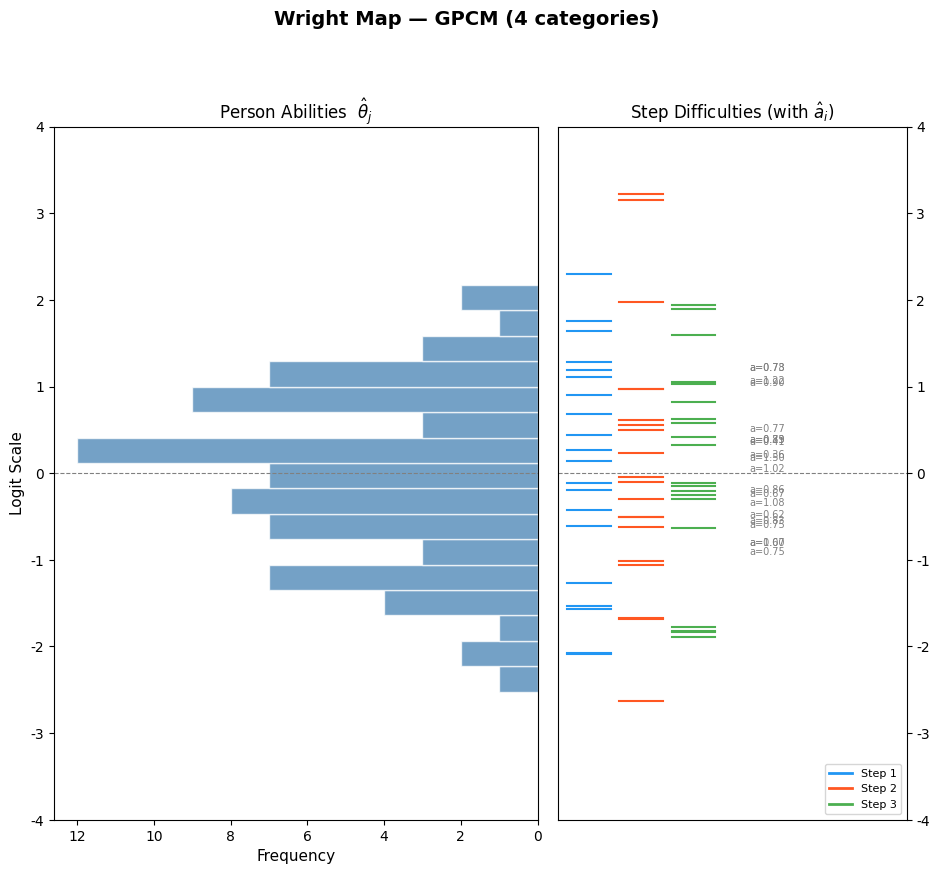

In [6]:
fig = plt.figure(figsize=(11, 9))
gs = gridspec.GridSpec(1, 2, width_ratios=[2.5, 1.8], wspace=0.05)
ax_p = fig.add_subplot(gs[0])
ax_i = fig.add_subplot(gs[1])
y_lim = (-4, 4)
step_colors = ['#2196F3', '#FF5722', '#4CAF50']

ax_p.hist(theta_est, bins=16, orientation='horizontal',
          color='steelblue', alpha=0.75, edgecolor='white')
ax_p.set_ylim(y_lim); ax_p.invert_xaxis()
ax_p.set_xlabel('Frequency', fontsize=11); ax_p.set_ylabel('Logit Scale', fontsize=11)
ax_p.set_title('Person Abilities  $\\hat{\\theta}_j$', fontsize=12)
ax_p.axhline(0, color='gray', linestyle='--', linewidth=0.8)

for i in range(I):
    for k in range(K - 1):
        dv = delta_est[i, k]
        ax_i.plot([0.05 + k * 0.3, 0.3 + k * 0.3], [dv, dv],
                  color=step_colors[k], linewidth=1.5)
    # label with a value
    mean_d = delta_est[i].mean()
    ax_i.text(1.1, mean_d, f'a={a_est[i]:.2f}', va='center', fontsize=7, color='gray')

ax_i.set_ylim(y_lim); ax_i.set_xlim(0, 2); ax_i.set_xticks([])
ax_i.set_yticks(range(-4, 5)); ax_i.yaxis.set_label_position('right'); ax_i.yaxis.tick_right()
ax_i.set_title('Step Difficulties (with $\\hat{a}_i$)', fontsize=12)
ax_i.axhline(0, color='gray', linestyle='--', linewidth=0.8)
for k in range(K - 1):
    ax_i.plot([], [], color=step_colors[k], linewidth=2, label=f'Step {k+1}')
ax_i.legend(loc='lower right', fontsize=8)

fig.suptitle('Wright Map — GPCM (4 categories)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'wright_map_gpcm.png'), dpi=120, bbox_inches='tight')
plt.show()

### 5b. Category Response Curves (CRC)

$$P(X_i = k \mid \theta) \propto \exp\!\left(\sum_{m=1}^{k} \hat{a}_i(\theta - \hat{\delta}_{im})\right)$$

**Interpretation**: Compared to the PCM, GPCM category curves are **steeper** for items with high discrimination $a_i$ and **flatter** for items with low $a_i$. High-$a_i$ items have narrowly-peaked modal categories, meaning each category is the most likely response over only a short ability range — implying high information in that region but quick transitions. Items with low $a_i$ have broad, overlapping curves, providing less precise measurement.

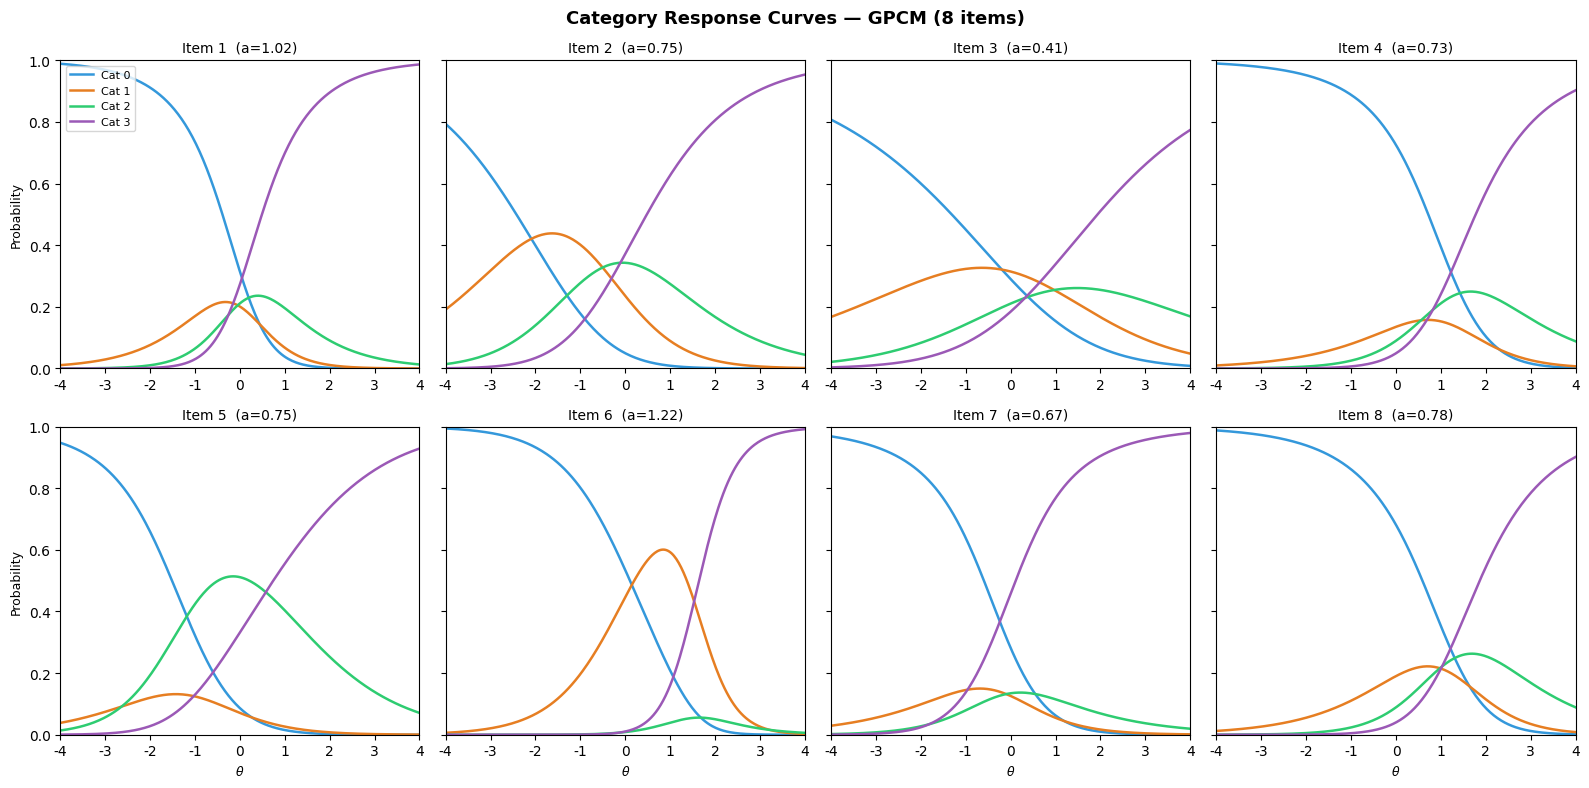

In [7]:
theta_range = np.linspace(-4, 4, 300)
cat_colors  = ['#3498DB', '#E67E22', '#2ECC71', '#9B59B6']

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)
axes = axes.ravel()

for idx, i in enumerate(range(min(8, I))):
    ax = axes[idx]
    for k in range(K):
        probs = [gpcm_probs(t, a_est[i], delta_est[i])[k] for t in theta_range]
        ax.plot(theta_range, probs, color=cat_colors[k], linewidth=1.8, label=f'Cat {k}')
    ax.set_title(f'Item {i+1}  (a={a_est[i]:.2f})', fontsize=10)
    ax.set_xlim(-4, 4); ax.set_ylim(0, 1)
    if idx >= 4: ax.set_xlabel('$\\theta$', fontsize=9)
    if idx in [0, 4]: ax.set_ylabel('Probability', fontsize=9)

axes[0].legend(fontsize=8, loc='upper left')
fig.suptitle('Category Response Curves — GPCM (8 items)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'crc_gpcm.png'), dpi=120, bbox_inches='tight')
plt.show()

### 5c. Test Characteristic Curve (TCC)

$$\text{TCC}(\theta) = \sum_{i=1}^{I} \sum_{k=0}^{K-1} k \cdot P(X_i = k \mid \theta)$$

**Interpretation**: Items with higher discrimination $a_i$ cause the TCC to rise more steeply near those items' central step difficulties. The non-uniform slope of the TCC across the ability range reflects the heterogeneous discrimination of the 20 items. Regions with steeper slope are where the test is most informative.

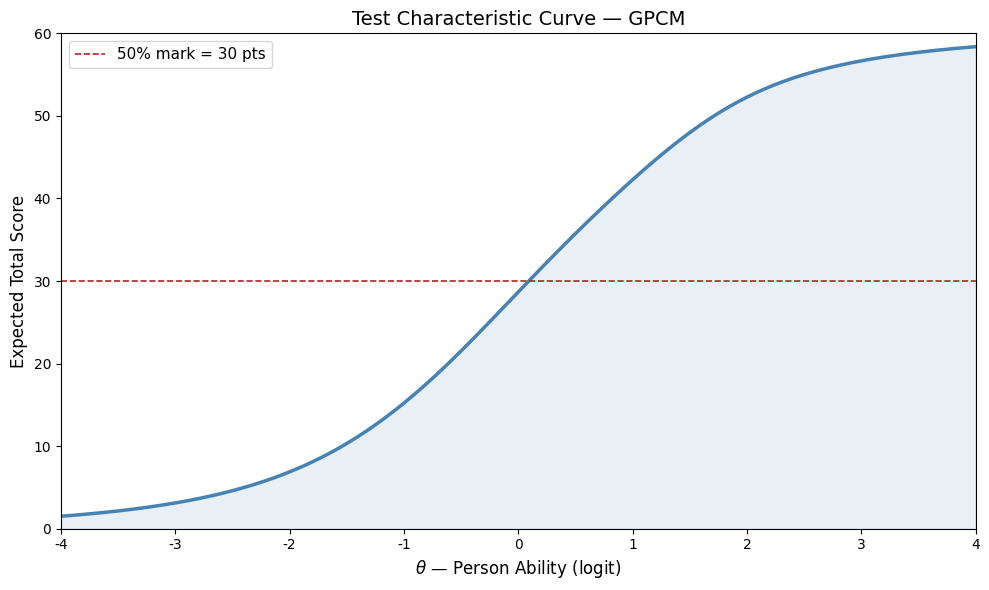

In [8]:
expected_score = np.zeros(len(theta_range))
for i in range(I):
    for t_idx, t in enumerate(theta_range):
        pr = gpcm_probs(t, a_est[i], delta_est[i])
        expected_score[t_idx] += np.dot(np.arange(K), pr)

max_score = I * (K - 1)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(theta_range, expected_score, color='steelblue', linewidth=2.5)
ax.fill_between(theta_range, 0, expected_score, alpha=0.12, color='steelblue')
ax.axhline(max_score / 2, color='firebrick', linestyle='--', linewidth=1.2,
           label=f'50% mark = {max_score//2} pts')
ax.set_xlabel('$\\theta$ — Person Ability (logit)', fontsize=12)
ax.set_ylabel('Expected Total Score', fontsize=12)
ax.set_title('Test Characteristic Curve — GPCM', fontsize=14)
ax.set_xlim(-4, 4); ax.set_ylim(0, max_score); ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'tcc_gpcm.png'), dpi=120, bbox_inches='tight')
plt.show()

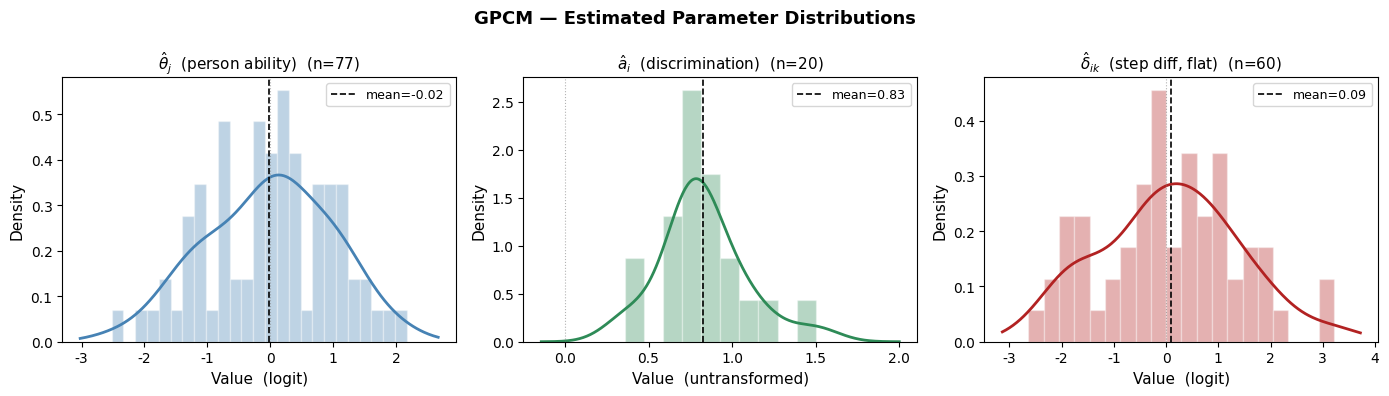

theta         : mean=-0.019  SD=0.993  range=[-2.52, 2.17]
a             : mean=0.827  SD=0.251  range=[0.36, 1.50]
delta (flat)  : mean=0.087  SD=1.308  range=[-2.63, 3.22]


In [9]:
# ── Posterior Parameter Density (Logit Scale) ─────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('GPCM — Estimated Parameter Distributions', fontsize=13, fontweight='bold')

delta_flat = delta_est.ravel()

panels = [
    (axes[0], theta_est,  r'$\hat{\theta}_j$  (person ability)',         'steelblue',  'logit'),
    (axes[1], a_est,      r'$\hat{a}_i$  (discrimination)',               'seagreen',   'untransformed'),
    (axes[2], delta_flat, r'$\hat{\delta}_{ik}$  (step diff, flat)',     'firebrick',  'logit'),
]

for ax, vals, title, color, unit in panels:
    ax.hist(vals, bins=max(10, len(vals)//3), density=True,
            color=color, alpha=0.35, edgecolor='white')
    if len(vals) >= 3:
        xs = np.linspace(vals.min() - 0.5, vals.max() + 0.5, 300)
        kde = gaussian_kde(vals, bw_method='scott')
        ax.plot(xs, kde(xs), color=color, linewidth=2)
    ax.axvline(vals.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'mean={vals.mean():.2f}')
    ax.axvline(0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.set_xlabel(f'Value  ({unit})', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{title}  (n={len(vals)})', fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'density_gpcm.png'), dpi=120, bbox_inches='tight')
plt.show()
for name, vals in [('theta', theta_est), ('a', a_est), ('delta (flat)', delta_flat)]:
    print(f"{name:14s}: mean={vals.mean():.3f}  SD={vals.std():.3f}  "
          f"range=[{vals.min():.2f}, {vals.max():.2f}]")
